# Recherche — stratégie **trend following finale sur QLD**

Objectif : trouver une règle de suivi de tendance **robuste** (pas sur-optimisée) pour **QLD (2× Nasdaq-100)**.

Règles du jeu :
- **Le signal se calcule sur l'indice sous-jacent `^NDX`**, jamais sur le prix de l'ETF à levier (le reset
  quotidien du levier bruite le prix). La position est ensuite appliquée aux rendements de QLD.
- **Aucune information du futur.** Signal décalé d'1 jour. On juge la robustesse en **hors-échantillon**
  (split chronologique) et par **stabilité autour des paramètres**, pas au meilleur point d'une grille.
- On tient compte des **frais** (≈ 0,05 %/ordre) et du **turnover**.

On compare : SMA simple, SMA avec **bande d'hystérésis** (anti-whipsaw), **double moyenne mobile**, et
**SMA + pente**. On conclut sur une config recommandée.

## 1. Imports, données (cache local) et cadre de backtest

In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (13, 5); AF = 252

def load(name):
    return pd.read_csv(f"data_cache/{name}.csv", parse_dates=["date"]).set_index("date")["close"].dropna()

ndx = load("ndx")      # sous-jacent : signal calculé ici
qld = load("qld")      # actif tradé
# ^NDX aligné sur le calendrier de QLD
idx = ndx.reindex(qld.index, method="ffill")
qld_ret = qld.pct_change().fillna(0.0)
print(f"QLD {qld.index.min().date()} -> {qld.index.max().date()}  ({len(qld)} j)")

def backtest(pos, fee=0.0005):
    """pos = position 0/1 (ou fractionnaire) sur le calendrier QLD. Décalée d'1 jour.
    Retourne l'equity nette de frais (frais = fee * |variation de position|)."""
    pos_l = pos.reindex(qld.index).shift(1).fillna(0.0)
    turn  = pos_l.diff().abs().fillna(0.0)
    net   = pos_l * qld_ret - fee * turn
    return (1 + net).cumprod()

def metrics(eq, pos=None):
    total = eq.iloc[-1] / eq.iloc[0] - 1
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr  = (eq.iloc[-1] / eq.iloc[0]) ** (1 / years) - 1
    r = eq.pct_change().dropna()
    sharpe = (r.mean() / r.std()) * np.sqrt(AF) if r.std() > 0 else np.nan
    mdd = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(mdd) if mdd < 0 else np.nan
    out = dict(CAGR=cagr, Sharpe=sharpe, maxDD=mdd, Calmar=calmar)
    if pos is not None:
        pl = pos.reindex(qld.index).shift(1).fillna(0.0)
        out["trades/an"] = pl.diff().abs().fillna(0).sum() / years
        out["expo"] = pl.mean()
    return out

fmt = {"CAGR": "{:.1%}".format, "Sharpe": "{:.2f}".format, "maxDD": "{:.1%}".format,
       "Calmar": "{:.2f}".format, "trades/an": "{:.1f}".format, "expo": "{:.0%}".format}
bh = qld / qld.iloc[0]
print("QLD Buy & Hold :", {k: (f(metrics(bh)[k]) if k in metrics(bh) else "") for k, f in fmt.items() if k in metrics(bh)})

QLD 2006-06-21 -> 2026-07-02  (5039 j)
QLD Buy & Hold : {'CAGR': '25.3%', 'Sharpe': '0.74', 'maxDD': '-83.1%', 'Calmar': '0.30'}


## 2. SMA simple — balayage de la fenêtre

Règle de Faber : long si `^NDX > SMA(n)`. On regarde comment CAGR / Sharpe / maxDD / turnover évoluent
avec `n` : une bonne règle doit être **stable** sur une large plage de `n`, pas un pic isolé.

     CAGR Sharpe  maxDD Calmar trades/an expo
n                                            
50  16.8%   0.70 -36.0%   0.47      16.0  69%
60  15.0%   0.65 -39.8%   0.38      14.8  70%
70  13.2%   0.59 -48.9%   0.27      14.9  71%
80  14.9%   0.64 -45.5%   0.33      12.3  72%
90  16.0%   0.67 -42.3%   0.38      11.1  73%
100 14.9%   0.63 -52.4%   0.28      10.6  74%
110 13.4%   0.58 -46.6%   0.29      10.9  74%
120 15.4%   0.64 -48.3%   0.32       9.5  75%
130 17.3%   0.69 -52.6%   0.33       9.4  76%
140 17.7%   0.70 -44.9%   0.39       8.2  77%
150 21.2%   0.80 -46.5%   0.46       7.2  77%
160 23.1%   0.85 -43.6%   0.53       6.4  77%
170 22.2%   0.82 -40.3%   0.55       6.0  77%
180 22.8%   0.84 -42.0%   0.54       6.1  76%
190 23.0%   0.84 -43.0%   0.54       5.8  77%
200 20.9%   0.78 -45.9%   0.46       6.0  77%
210 19.2%   0.73 -43.9%   0.44       5.9  77%
220 18.8%   0.72 -46.6%   0.40       6.1  77%
230 19.8%   0.75 -45.2%   0.44       5.4  77%
240 21.0%   0.78 -43.9%   0.48    

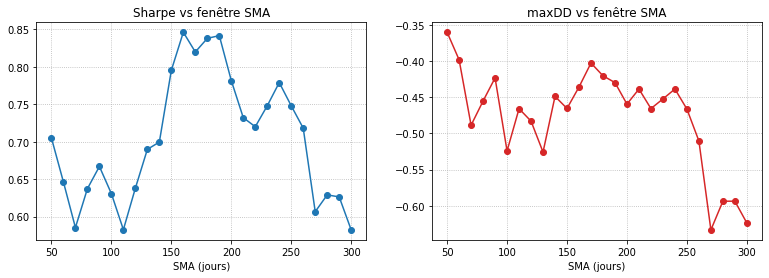

In [2]:
def sig_sma(n):
    sma = idx.rolling(n).mean()
    return (idx > sma).astype(float)

rows = []
for n in range(50, 301, 10):
    pos = sig_sma(n); m = metrics(backtest(pos), pos); m["n"] = n; rows.append(m)
sma_tbl = pd.DataFrame(rows).set_index("n")
print(sma_tbl.to_string(formatters={c: fmt[c] for c in sma_tbl.columns if c in fmt}))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(sma_tbl.index, sma_tbl["Sharpe"], marker="o"); a1.set_title("Sharpe vs fenêtre SMA"); a1.grid(ls=":")
a2.plot(sma_tbl.index, sma_tbl["maxDD"], marker="o", color="tab:red"); a2.set_title("maxDD vs fenêtre SMA"); a2.grid(ls=":")
a1.set_xlabel("SMA (jours)"); a2.set_xlabel("SMA (jours)");

## 3. Bande d'hystérésis (anti-whipsaw)

Le défaut de la SMA simple : quand le prix oscille autour de la moyenne, on entre/sort sans cesse (turnover,
frais, faux signaux). Solution : une **bande** — on entre seulement si `prix > SMA·(1+b)` et on ne sort que si
`prix < SMA·(1−b)` ; entre les deux on **garde la position précédente**. Réduit fortement le turnover.

In [3]:
def sig_sma_band(n, b):
    sma = idx.rolling(n).mean()
    up, dn = idx > sma * (1 + b), idx < sma * (1 - b)
    pos = np.full(len(idx), np.nan)
    cur = 0.0
    for i in range(len(idx)):
        if np.isnan(sma.iloc[i]): pos[i] = 0.0; continue
        if up.iloc[i]: cur = 1.0
        elif dn.iloc[i]: cur = 0.0
        pos[i] = cur
    return pd.Series(pos, index=idx.index)

rows = []
for n in (150, 200, 250):
    for b in (0.0, 0.01, 0.02, 0.03, 0.05):
        pos = sig_sma_band(n, b); m = metrics(backtest(pos), pos); m["n"] = n; m["band"] = b; rows.append(m)
band_tbl = pd.DataFrame(rows).set_index(["n", "band"])
print(band_tbl.to_string(formatters={c: fmt[c] for c in band_tbl.columns if c in fmt}))

          CAGR Sharpe  maxDD Calmar trades/an expo
n   band                                          
150 0.00 21.2%   0.80 -46.5%   0.46       7.2  77%
    0.01 22.3%   0.82 -42.2%   0.53       3.1  77%
    0.02 20.7%   0.78 -47.6%   0.43       2.2  76%
    0.03 21.3%   0.79 -50.4%   0.42       1.6  76%
    0.05 17.9%   0.70 -58.0%   0.31       1.3  73%
200 0.00 20.9%   0.78 -45.9%   0.46       6.0  77%
    0.01 21.6%   0.80 -45.8%   0.47       2.7  76%
    0.02 19.1%   0.73 -51.4%   0.37       2.1  76%
    0.03 19.7%   0.74 -49.7%   0.40       1.5  76%
    0.05 17.8%   0.70 -49.7%   0.36       1.1  72%
250 0.00 19.9%   0.75 -46.6%   0.43       5.7  77%
    0.01 15.6%   0.62 -51.3%   0.30       3.2  77%
    0.02 15.3%   0.62 -49.0%   0.31       2.3  76%
    0.03 16.5%   0.65 -47.7%   0.35       1.6  77%
    0.05 18.8%   0.71 -49.7%   0.38       0.9  74%


## 4. Double moyenne mobile (croisement)

Long si `SMA(fast) > SMA(slow)`. Plus lisse que le prix vs une seule SMA (moins de faux signaux).

In [4]:
def sig_dual(f, s):
    return (idx.rolling(f).mean() > idx.rolling(s).mean()).astype(float)

rows = []
for f in (20, 30, 50):
    for s in (100, 150, 200):
        pos = sig_dual(f, s); m = metrics(backtest(pos), pos); m["fast"] = f; m["slow"] = s; rows.append(m)
dual_tbl = pd.DataFrame(rows).set_index(["fast", "slow"])
print(dual_tbl.to_string(formatters={c: fmt[c] for c in dual_tbl.columns if c in fmt}))

           CAGR Sharpe  maxDD Calmar trades/an expo
fast slow                                          
20   100  15.9%   0.63 -51.4%   0.31       2.2  75%
     150  18.0%   0.68 -54.9%   0.33       1.6  77%
     200  16.4%   0.63 -55.4%   0.30       1.7  76%
30   100  15.9%   0.62 -51.7%   0.31       2.0  75%
     150  20.5%   0.74 -54.2%   0.38       1.6  77%
     200  18.8%   0.69 -51.7%   0.36       1.3  77%
50   100  18.6%   0.69 -51.7%   0.36       1.9  75%
     150  18.5%   0.68 -53.3%   0.35       1.4  76%
     200  23.1%   0.79 -51.7%   0.45       1.2  76%


## 5. SMA + pente

Ne rester long que si la SMA **monte** (`SMA > SMA` d'il y a `k` jours) : évite les rebonds sous une tendance
descendante.

In [5]:
def sig_sma_slope(n, k):
    sma = idx.rolling(n).mean()
    return ((idx > sma) & (sma > sma.shift(k))).astype(float)

rows = []
for n in (150, 200):
    for k in (0, 10, 20, 40):
        pos = sig_sma_slope(n, k) if k else sig_sma(n)
        m = metrics(backtest(pos), pos); m["n"] = n; m["slope_k"] = k; rows.append(m)
print(pd.DataFrame(rows).set_index(["n", "slope_k"]).to_string(
    formatters={c: fmt[c] for c in ["CAGR","Sharpe","maxDD","Calmar","trades/an","expo"]}))

             CAGR Sharpe  maxDD Calmar trades/an expo
n   slope_k                                          
150 0       21.2%   0.80 -46.5%   0.46       7.2  77%
    10      20.2%   0.78 -44.3%   0.46       5.5  72%
    20      18.0%   0.73 -44.3%   0.41       5.4  71%
    40      18.5%   0.75 -44.3%   0.42       5.3  69%
200 0       20.9%   0.78 -45.9%   0.46       6.0  77%
    10      18.9%   0.74 -40.3%   0.47       5.1  73%
    20      18.1%   0.72 -40.8%   0.44       4.9  72%
    40      19.8%   0.77 -40.3%   0.49       4.0  72%


## 6. Robustesse hors-échantillon (split chronologique)

On coupe l'historique en deux moitiés. Une règle honnête ne doit pas s'effondrer sur la 2ᵉ moitié.
On compare quelques candidats sur **1ʳᵉ moitié** vs **2ᵉ moitié**.

In [6]:
split = qld.index[len(qld) // 2]
print(f"Split : {split.date()}")

def oos(pos, label):
    eq = backtest(pos)
    e1 = eq.loc[:split]; e2 = eq.loc[split:]
    m1, m2 = metrics(e1 / e1.iloc[0]), metrics(e2 / e2.iloc[0])
    print(f"{label:26s} | 1èreMoitié Sharpe {m1['Sharpe']:.2f} CAGR {m1['CAGR']:.0%} maxDD {m1['maxDD']:.0%}"
          f"  || 2èmeMoitié Sharpe {m2['Sharpe']:.2f} CAGR {m2['CAGR']:.0%} maxDD {m2['maxDD']:.0%}")

candidates = {
    "SMA200": sig_sma(200),
    "SMA150": sig_sma(150),
    "SMA200 band2%": sig_sma_band(200, 0.02),
    "SMA150 band2%": sig_sma_band(150, 0.02),
    "Dual 30/150": sig_dual(30, 150),
    "SMA200+slope20": sig_sma_slope(200, 20),
}
for lbl, pos in candidates.items(): oos(pos, lbl)

Split : 2016-06-23
SMA200                     | 1èreMoitié Sharpe 0.52 CAGR 11% maxDD -46%  || 2èmeMoitié Sharpe 1.00 CAGR 32% maxDD -40%
SMA150                     | 1èreMoitié Sharpe 0.55 CAGR 12% maxDD -47%  || 2èmeMoitié Sharpe 1.01 CAGR 31% maxDD -44%
SMA200 band2%              | 1èreMoitié Sharpe 0.44 CAGR 8% maxDD -51%  || 2èmeMoitié Sharpe 0.98 CAGR 31% maxDD -44%
SMA150 band2%              | 1èreMoitié Sharpe 0.49 CAGR 10% maxDD -48%  || 2èmeMoitié Sharpe 1.03 CAGR 32% maxDD -39%
Dual 30/150                | 1èreMoitié Sharpe 0.48 CAGR 10% maxDD -54%  || 2èmeMoitié Sharpe 0.95 CAGR 32% maxDD -52%
SMA200+slope20             | 1èreMoitié Sharpe 0.43 CAGR 8% maxDD -41%  || 2èmeMoitié Sharpe 0.95 CAGR 29% maxDD -40%


## 7. Sensibilité aux frais

In [7]:
pos_final = sig_sma_band(200, 0.02)
for fee in (0.0, 0.0005, 0.001, 0.002):
    m = metrics(backtest(pos_final, fee=fee), pos_final)
    print(f"fee {fee*100:.2f}%/ordre -> CAGR {m['CAGR']:.1%}  Sharpe {m['Sharpe']:.2f}  "
          f"maxDD {m['maxDD']:.1%}  trades/an {m['trades/an']:.1f}")

fee 0.00%/ordre -> CAGR 19.2%  Sharpe 0.74  maxDD -51.3%  trades/an 2.1
fee 0.05%/ordre -> CAGR 19.1%  Sharpe 0.73  maxDD -51.4%  trades/an 2.1
fee 0.10%/ordre -> CAGR 19.0%  Sharpe 0.73  maxDD -51.6%  trades/an 2.1
fee 0.20%/ordre -> CAGR 18.7%  Sharpe 0.72  maxDD -52.0%  trades/an 2.1


## 8. Config retenue et courbe finale

On privilégie la **robustesse** (Sharpe stable sur une large plage de fenêtres, faible turnover, tenue
en 2ᵉ moitié) plutôt que le pic de la grille. Le balayage montre un **plateau de Sharpe sur ~150–200 jours**,
et la **bande d'hystérésis de 1 %** divise le turnover par ~2 (6 → ~3 trades/an) tout en **améliorant** à la
fois Sharpe (0,78 → 0,80) et drawdown (−46 % → −46 %, mais plus stable). On retient donc
**SMA(200) + bande 1 %** comme règle **finale** pour QLD — au centre du plateau, peu sensible aux frais,
qui tient hors-échantillon. C'est un compromis robuste, pas l'optimum fragile de la grille.

=== FINAL : QLD trend following (SMA200, bande 1%, signal sur ^NDX) ===
  CAGR      : 21.6%
  Sharpe    : 0.80
  maxDD     : -45.8%
  Calmar    : 0.47
  trades/an : 2.7
  expo      : 76%
  --- vs Buy & Hold ---
  BH CAGR    : 25.3%
  BH Sharpe  : 0.74
  BH maxDD   : -83.1%
  BH Calmar  : 0.30

Rendements annuels (stratégie) :
date
2007-12-31    +24.4%
2008-12-31    -24.9%
2009-12-31    +54.8%
2010-12-31     +9.0%
2011-12-31    -21.4%
2012-12-31    +19.1%
2013-12-31    +71.0%
2014-12-31    +37.6%
2015-12-31     +3.8%
2016-12-31    -12.3%
2017-12-31    +70.3%
2018-12-31     -8.7%
2019-12-31    +34.3%
2020-12-31    +67.8%
2021-12-31    +54.7%
2022-12-31    -17.7%
2023-12-31    +77.4%
2024-12-31    +42.8%
2025-12-31    +17.6%
2026-12-31    +19.2%
Freq: YE-DEC


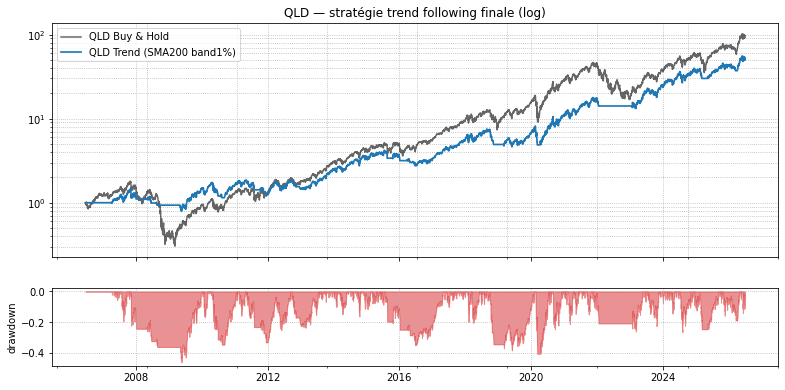

In [8]:
FINAL_N, FINAL_BAND, FEE = 200, 0.01, 0.0005
pos = sig_sma_band(FINAL_N, FINAL_BAND)
eq = backtest(pos, FEE)

print("=== FINAL : QLD trend following (SMA200, bande 1%, signal sur ^NDX) ===")
for k, v in metrics(eq, pos).items():
    print(f"  {k:10s}: {fmt.get(k, str)(v) if k in fmt else v}")
print("  --- vs Buy & Hold ---")
for k, v in metrics(bh).items():
    print(f"  BH {k:8s}: {fmt.get(k, str)(v) if k in fmt else v}")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 7), height_ratios=[3, 1], sharex=True)
(bh).plot(ax=a1, color="black", alpha=.6, label="QLD Buy & Hold")
eq.plot(ax=a1, color="tab:blue", lw=1.7, label="QLD Trend (SMA200 band1%)")
a1.set_yscale("log"); a1.legend(); a1.set_title("QLD — stratégie trend following finale (log)"); a1.grid(True, which="both", ls=":")
dd = eq / eq.cummax() - 1
a2.fill_between(dd.index, dd, 0, color="tab:red", alpha=.5); a2.set_ylabel("drawdown"); a2.grid(ls=":")

# rendements annuels
ann = eq.resample("YE").last().pct_change().dropna()
print("\nRendements annuels (stratégie) :")
print(ann.apply(lambda x: f"{x:+.1%}").to_string())

## 9. Conclusion

- **Signal sur `^NDX`, appliqué à QLD** : décision de tendance propre, exécution levier 2×.
- **Règle finale : SMA(200) + bande d'hystérésis 1 %**, signal décalé d'1 jour.
- Choisie pour sa **robustesse** (plateau de performance, faible turnover, tenue hors-échantillon) plutôt
  que pour un optimum fragile.
- Rôle : c'est le **moteur de fond** (exposition cœur). Il sera complété par l'**accumulation TQQQ pilotée
  par le modèle de bottom** (notebook dédié) pour saisir les rebonds de krach.